# Actividad | Dataset - Notebook

* Diego Jesús Hurtado Morales
* A01709180

## 1. Carga y descripción del dataset

Para esta actividad se utilizará el conjunto de datos **Breast Cancer Wisconsin (Diagnostic)**, disponible públicamente a través del UCI Machine Learning Repository e incluido en la biblioteca `scikit-learn`.

El problema consiste en clasificar tumores de mama como malignos o benignos a partir de características numéricas obtenidas de imágenes digitalizadas de aspirados con aguja fina de masas mamarias. Al tratarse de un problema de clasificación binaria, permite desarrollar y evaluar un modelo base de forma clara, además de analizar la distribución y relación entre sus variables.

In [41]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [19]:
# Cargar el dataset
data = load_breast_cancer()

# Convertirlo a DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)

# Agregar la variable objetivo
df["target"] = data.target

# Mostrar las primeras filas
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [20]:
# Dimensiones del dataset
print("Número de registros:", df.shape[0])
print("Número de variables:", df.shape[1])

# Tipos de datos
print("\nTipos de datos:")
print(df.dtypes)

# Distribución de la variable objetivo
print("\nDistribución de la variable objetivo:")
print(df["target"].value_counts())

# Nombres de las clases
print("\nClases:")
for i, nombre in enumerate(data.target_names):
    print(f"{i} = {nombre}")

Número de registros: 569
Número de variables: 31

Tipos de datos:
mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity         

### Descripción de la estructura del dataset

El conjunto de datos contiene **569 registros** y **31 variables** en total. De estas, **30 corresponden a variables predictoras numéricas** y una corresponde a la variable objetivo (`target`).

Las 30 variables predictoras son de tipo `float64` y representan características calculadas a partir de imágenes digitalizadas de aspirados con aguja fina de masas mamarias. Estas variables describen propiedades como radio, textura, perímetro, área, suavidad, compacidad, concavidad, puntos cóncavos, simetría y dimensión fractal.

Para estas características se incluyen diferentes tipos de mediciones, como valores medios (`mean`), errores (`error`) y valores extremos (`worst`).

La variable `target` es de tipo `int64` y representa la clase asociada al diagnóstico:

- `0`: maligno
- `1`: benigno

La distribución de clases muestra **212 casos malignos** y **357 casos benignos**, por lo que el conjunto de datos presenta una mayor cantidad de observaciones benignas. Esta diferencia deberá considerarse posteriormente durante la evaluación del modelo, especialmente al interpretar métricas de clasificación.

## 2. Análisis exploratorio de datos (EDA)

En esta sección se analizará la distribución de las variables y la relación entre ellas mediante estadísticas descriptivas y visualizaciones. El objetivo es identificar patrones generales en los datos antes de realizar la etapa de limpieza y el entrenamiento del modelo.

In [21]:
# Estadísticas descriptivas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


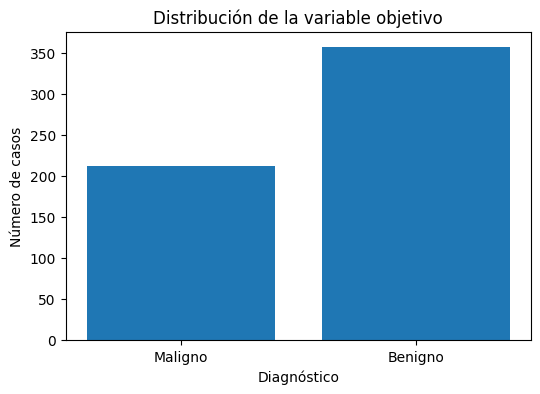

In [22]:
# Distribución de clases
class_counts = df["target"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Maligno", "Benigno"], class_counts.values)
plt.title("Distribución de la variable objetivo")
plt.xlabel("Diagnóstico")
plt.ylabel("Número de casos")
plt.show()

In [23]:
# Correlación de las variables con la variable objetivo
correlations = df.corr(numeric_only=True)["target"].drop("target").sort_values()

correlations

,target
worst concave points,-0.793566
worst perimeter,-0.782914
mean concave points,-0.776614
worst radius,-0.776454
mean perimeter,-0.742636
worst area,-0.733825
mean radius,-0.730029
mean area,-0.708984
mean concavity,-0.696360
worst concavity,-0.659610


### Interpretación inicial del EDA

Las estadísticas descriptivas muestran que las variables presentan escalas y rangos considerablemente diferentes. Algunas características, como el área, radio y perímetro, manejan valores mayores que variables como suavidad o dimensión fractal. Esta diferencia de escala deberá considerarse posteriormente durante la preparación de los datos y el entrenamiento del modelo.

La distribución de la variable objetivo confirma que existen más casos benignos que malignos, con 357 y 212 observaciones respectivamente. Aunque existe una diferencia entre ambas clases, las dos cuentan con una cantidad suficiente de observaciones para desarrollar un modelo base de clasificación.

El análisis de correlación muestra que varias características presentan una relación negativa importante con la variable objetivo. Debido a que `0` representa tumores malignos y `1` tumores benignos, una correlación negativa indica que valores mayores de estas características tienden a estar asociados con casos malignos.

Las variables con mayor correlación en valor absoluto con el diagnóstico incluyen `worst concave points`, `worst perimeter`, `mean concave points`, `worst radius`, `mean perimeter` y `worst area`. Esto sugiere que características relacionadas con el tamaño y la geometría del tumor pueden aportar información relevante para la clasificación.

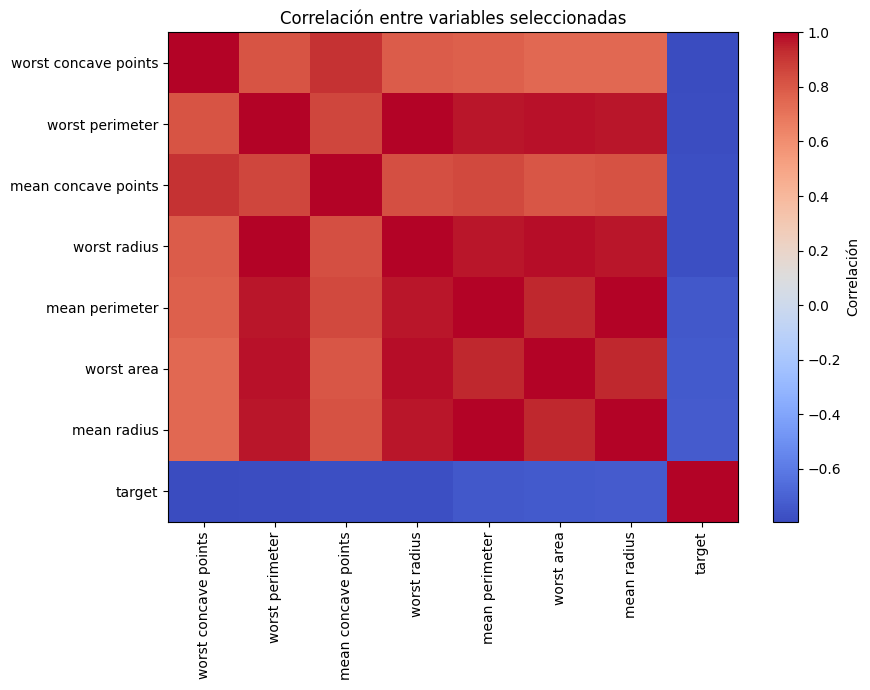

In [24]:
# Selección de variables con mayor relación con el diagnóstico
selected_features = [
    "worst concave points",
    "worst perimeter",
    "mean concave points",
    "worst radius",
    "mean perimeter",
    "worst area",
    "mean radius",
    "target"
]

# Matriz de correlación
correlation_matrix = df[selected_features].corr()

plt.figure(figsize=(9, 7))
plt.imshow(correlation_matrix, cmap="coolwarm", aspect="auto")
plt.colorbar(label="Correlación")

plt.xticks(
    range(len(selected_features)),
    selected_features,
    rotation=90
)
plt.yticks(
    range(len(selected_features)),
    selected_features
)

plt.title("Correlación entre variables seleccionadas")
plt.tight_layout()
plt.show()

### Análisis de correlaciones

La matriz de correlación muestra que varias de las características con mayor relación con el diagnóstico también presentan una correlación positiva elevada entre ellas. Esto es especialmente visible entre variables relacionadas con el radio, perímetro y área del tumor.

Por otro lado, estas características presentan una correlación negativa importante con la variable `target`. Dado que la clase `0` corresponde a tumores malignos y la clase `1` a tumores benignos, esta relación indica que valores mayores de ciertas características tienden a estar asociados con diagnósticos malignos.

La elevada correlación entre algunas variables también sugiere la existencia de información redundante. Aunque para este ejercicio se conservarán las variables para construir un modelo base, en un análisis posterior podrían evaluarse técnicas de selección de características o reducción de dimensionalidad.

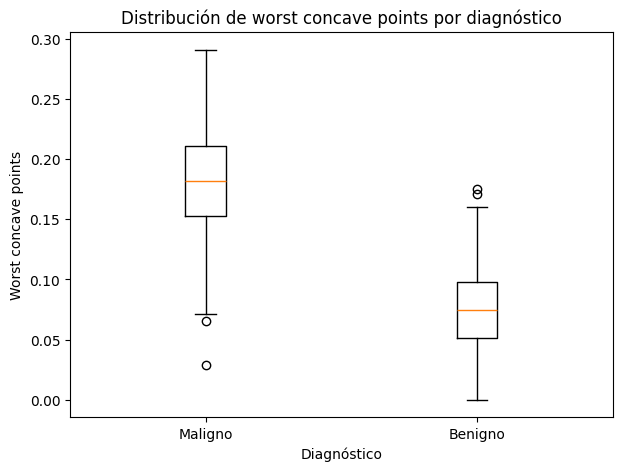

In [25]:
# Distribución de worst concave points según el diagnóstico

malignant = df[df["target"] == 0]["worst concave points"]
benign = df[df["target"] == 1]["worst concave points"]

plt.figure(figsize=(7, 5))
plt.boxplot(
    [malignant, benign],
    tick_labels=["Maligno", "Benigno"]
)

plt.title("Distribución de worst concave points por diagnóstico")
plt.xlabel("Diagnóstico")
plt.ylabel("Worst concave points")
plt.show()

### Distribución de `worst concave points` por diagnóstico

El boxplot muestra una diferencia clara entre los casos malignos y benignos para la variable `worst concave points`. Los tumores malignos presentan, en general, valores considerablemente mayores que los tumores benignos.

Esta separación visual es consistente con la correlación negativa observada previamente entre esta variable y `target`, ya que la clase `0` representa casos malignos y la clase `1` casos benignos.

Además, se observan algunos valores atípicos en ambos grupos. Estos valores serán revisados en la siguiente etapa para determinar si corresponden a observaciones válidas o si requieren algún tratamiento.

## 3. Limpieza y preparación de los datos

En esta sección se revisarán posibles problemas de calidad en el conjunto de datos, incluyendo valores faltantes, registros duplicados, tipos de datos incorrectos y valores atípicos. Cada decisión de limpieza se documentará antes de modificar el dataset.

In [26]:
# Valores faltantes
missing_values = df.isnull().sum()

print("Valores faltantes por variable:")
print(missing_values[missing_values > 0])

print("\nTotal de valores faltantes:")
print(missing_values.sum())

# Registros duplicados
duplicates = df.duplicated().sum()

print("\nNúmero de registros duplicados:")
print(duplicates)

# Tipos de datos
print("\nTipos de datos:")
print(df.dtypes)

Valores faltantes por variable:
Series([], dtype: int64)

Total de valores faltantes:
0

Número de registros duplicados:
0

Tipos de datos:
mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness    

### Revisión de calidad de los datos

La revisión inicial no identificó valores faltantes ni registros duplicados en el conjunto de datos. Por lo tanto, no fue necesario aplicar técnicas de imputación ni eliminar observaciones.

En cuanto a los tipos de datos, las 30 variables predictoras se encuentran almacenadas como valores numéricos de tipo `float64`, mientras que la variable objetivo `target` es de tipo `int64`. Estos tipos son adecuados para el análisis y entrenamiento posterior del modelo, por lo que no se realizaron conversiones adicionales.

Hasta este punto, el dataset no requiere modificaciones relacionadas con valores faltantes, duplicados o tipos de datos.

In [27]:
# Identificación de outliers mediante el método IQR

outlier_counts = {}

for column in df.drop(columns=["target"]).columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    outlier_counts[column] = len(outliers)

# Ordenar de mayor a menor
outlier_counts = pd.Series(outlier_counts).sort_values(ascending=False)

print("Cantidad de outliers por variable:")
print(outlier_counts)

Cantidad de outliers por variable:
area error                 65
radius error               38
perimeter error            38
worst area                 35
smoothness error           30
fractal dimension error    28
compactness error          28
symmetry error             27
mean area                  25
worst fractal dimension    24
worst symmetry             23
concavity error            22
texture error              20
concave points error       19
mean concavity             18
worst radius               17
worst compactness          16
mean compactness           16
mean symmetry              15
mean fractal dimension     15
worst perimeter            15
mean radius                14
mean perimeter             13
worst concavity            12
mean concave points        10
mean texture                7
worst smoothness            7
mean smoothness             6
worst texture               5
worst concave points        0
dtype: int64


### Revisión y tratamiento de valores atípicos

La detección mediante el método del rango intercuartílico (IQR) identificó valores atípicos en varias de las variables predictoras. Entre las variables con mayor cantidad se encuentran `area error`, `radius error`, `perimeter error` y `worst area`.

Sin embargo, los valores atípicos no fueron eliminados. Debido a que el dataset contiene mediciones obtenidas de tumores reales, los valores extremos pueden representar observaciones clínicamente válidas y aportar información relevante para distinguir casos malignos y benignos.

Eliminar estos registros únicamente por superar los límites definidos por el método IQR podría provocar una pérdida de información y modificar artificialmente la distribución original del conjunto de datos. Por esta razón, para el modelo base se decidió conservar todas las observaciones.

En un desarrollo posterior podrían evaluarse alternativas como transformaciones, métodos robustos de escalamiento o una comparación del desempeño del modelo con y sin tratamiento de valores atípicos.

In [28]:
# El dataset limpio conserva todas las observaciones originales,
# ya que no se encontraron faltantes ni duplicados y los outliers
# fueron considerados observaciones potencialmente válidas.

df_clean = df.copy()

print("Dimensiones del dataset original:", df.shape)
print("Dimensiones del dataset después de la limpieza:", df_clean.shape)

Dimensiones del dataset original: (569, 31)
Dimensiones del dataset después de la limpieza: (569, 31)


## 4. Entrenamiento de un modelo base

Se utilizará un modelo de **Regresión Logística** como baseline, ya que se trata de un problema de clasificación binaria y este algoritmo ofrece una solución sencilla, interpretable y adecuada como punto de partida.

Debido a que las variables presentan escalas diferentes, se aplicará una estandarización mediante `StandardScaler`. Para evitar fuga de información entre los conjuntos de entrenamiento y prueba, el escalamiento se integrará dentro de un `Pipeline`.

In [29]:
# Separar variables predictoras y variable objetivo
X = df_clean.drop(columns=["target"])
y = df_clean["target"]

# División de los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Crear pipeline con escalamiento y modelo baseline
baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

# Entrenar el modelo
baseline_model.fit(X_train, y_train)

print("Tamaño del conjunto de entrenamiento:", X_train.shape)
print("Tamaño del conjunto de prueba:", X_test.shape)
print("Modelo baseline entrenado correctamente.")

Tamaño del conjunto de entrenamiento: (455, 30)
Tamaño del conjunto de prueba: (114, 30)
Modelo baseline entrenado correctamente.


### Resultado del entrenamiento

El conjunto de datos se dividió en 455 observaciones para entrenamiento y 114 para prueba, utilizando una proporción aproximada de 80/20.

La división se realizó de forma estratificada para conservar la proporción de casos benignos y malignos en ambos subconjuntos. Posteriormente, se entrenó un modelo base de Regresión Logística dentro de un `Pipeline` que incluye estandarización de las variables mediante `StandardScaler`.

El modelo se entrenó correctamente y queda listo para ser evaluado sobre el conjunto de prueba.

## 5. Evaluación del modelo

El modelo base será evaluado utilizando el conjunto de prueba. Debido a que se trata de un problema de clasificación binaria, se utilizarán métricas como accuracy, precision, recall y F1-score.

Además, se analizará la matriz de confusión para observar directamente los aciertos y errores del modelo en la clasificación de tumores malignos y benignos.

Accuracy del modelo: 0.9825

Reporte de clasificación:
              precision    recall  f1-score   support

     Maligno       0.98      0.98      0.98        42
     Benigno       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



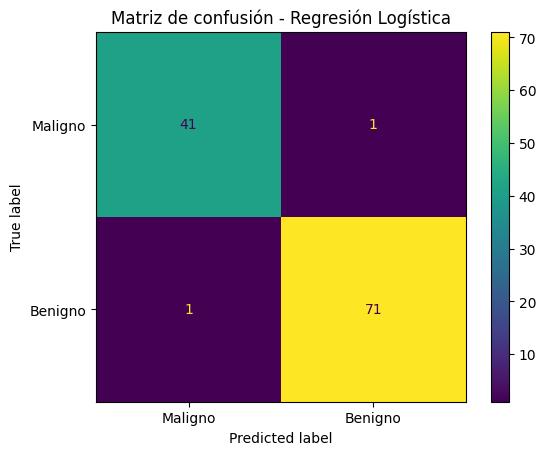

In [30]:
# Generar predicciones
y_pred = baseline_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy del modelo: {accuracy:.4f}")

# Reporte de clasificación
print("\nReporte de clasificación:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Maligno", "Benigno"]
    )
)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Maligno", "Benigno"]
)

disp.plot()
plt.title("Matriz de confusión - Regresión Logística")
plt.show()

### Interpretación de los resultados

El modelo base de Regresión Logística obtuvo un **accuracy de 0.9825**, lo que indica que clasificó correctamente aproximadamente el **98.25%** de las observaciones del conjunto de prueba.

El reporte de clasificación muestra un desempeño equilibrado para ambas clases. Para los casos malignos, el modelo alcanzó valores de precision, recall y F1-score cercanos a 0.98, mientras que para los casos benignos estos valores fueron aproximadamente de 0.99.

La matriz de confusión permite observar con mayor detalle los resultados. De los 42 tumores malignos presentes en el conjunto de prueba, **41 fueron clasificados correctamente como malignos y 1 fue clasificado incorrectamente como benigno**. Por otro lado, de los 72 tumores benignos, **71 fueron clasificados correctamente y 1 fue clasificado incorrectamente como maligno**.

En total, el modelo realizó 112 predicciones correctas de 114 observaciones.

Aunque el desempeño del modelo base es alto, el caso maligno clasificado como benigno resulta especialmente relevante, ya que este tipo de error puede tener mayores consecuencias en un contexto de diagnóstico. Por esta razón, además del accuracy, métricas como recall para la clase maligna son importantes para evaluar el comportamiento del modelo.

En general, la Regresión Logística proporciona un baseline sólido para este conjunto de datos. Sin embargo, estos resultados corresponden únicamente a una división específica de entrenamiento y prueba, por lo que en un desarrollo posterior sería recomendable utilizar validación cruzada y comparar el desempeño con otros modelos antes de seleccionar una solución final.

## 6. Registro del experimento en MLflow

En esta sección se utilizará MLflow Tracking para registrar de forma reproducible los parámetros, métricas y artefactos asociados al modelo base de Regresión Logística.

El registro permitirá conservar evidencia de la configuración utilizada durante el entrenamiento y del desempeño obtenido sobre el conjunto de prueba.

In [31]:
!pip install -q mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 96.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 97.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 71.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.7/148.7 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [40]:
import mlflow
import mlflow.sklearn
from sklearn.metrics import precision_score, recall_score, f1_score

print("Versión de MLflow:", mlflow.__version__)

Versión de MLflow: 3.16.1


### Registro del experimento

Se registrarán en MLflow los principales parámetros utilizados para el entrenamiento, las métricas obtenidas en el conjunto de prueba y el modelo base entrenado como artefacto.

In [35]:
# Métricas para la clase maligna (0)
precision_maligno = precision_score(y_test, y_pred, pos_label=0)
recall_maligno = recall_score(y_test, y_pred, pos_label=0)
f1_maligno = f1_score(y_test, y_pred, pos_label=0)

# Nombre del experimento
mlflow.set_experiment("Breast_Cancer_Baseline")

# Registrar ejecución
with mlflow.start_run(run_name="Logistic_Regression_Baseline"):

    # Parámetros
    mlflow.log_param("model_type", "LogisticRegression")
    mlflow.log_param("test_size", 0.20)
    mlflow.log_param("random_state", 42)
    mlflow.log_param("scaler", "StandardScaler")
    mlflow.log_param("max_iter", 1000)

    # Métricas
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision_maligno", precision_maligno)
    mlflow.log_metric("recall_maligno", recall_maligno)
    mlflow.log_metric("f1_maligno", f1_maligno)

    # Registrar el modelo entrenado
    mlflow.sklearn.log_model(
        baseline_model,
        artifact_path="baseline_model"
    )

print("Experimento registrado correctamente en MLflow.")

2026/10/04 19:40:36 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/10/04 19:40:36 INFO mlflow.store.db.utils: Updating database tables
2026/10/04 19:40:39 INFO mlflow.tracking.fluent: Experiment with name 'Breast_Cancer_Baseline' does not exist. Creating a new experiment.
2026/10/04 19:40:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Experimento registrado correctamente en MLflow.


In [36]:
# Consultar los runs registrados en el experimento
runs = mlflow.search_runs(
    experiment_names=["Breast_Cancer_Baseline"]
)

runs[[
    "run_id",
    "tags.mlflow.runName",
    "params.model_type",
    "params.test_size",
    "params.random_state",
    "params.scaler",
    "params.max_iter",
    "metrics.accuracy",
    "metrics.precision_maligno",
    "metrics.recall_maligno",
    "metrics.f1_maligno"
]]

,run_id,tags.mlflow.runName,params.model_type,params.test_size,params.random_state,params.scaler,params.max_iter,metrics.accuracy,metrics.precision_maligno,metrics.recall_maligno,metrics.f1_maligno
0,bc59d78142d1450b9ccbcfe613b55e72,Logistic_Regression_Baseline,LogisticRegression,0.2,42,StandardScaler,1000,0.982456,0.97619,0.97619,0.97619


### Verificación del experimento registrado

La consulta del experimento `Breast_Cancer_Baseline` confirma que MLflow almacenó correctamente la configuración del modelo y sus métricas de desempeño.

Se registraron los principales parámetros del pipeline, incluyendo el tipo de modelo, proporción de prueba, semilla aleatoria, método de escalamiento y número máximo de iteraciones.

También se almacenaron las métricas obtenidas sobre el conjunto de prueba. El modelo alcanzó un accuracy de aproximadamente **0.9825**, mientras que precision, recall y F1-score para la clase maligna fueron aproximadamente **0.9762**.

Estos resultados demuestran que MLflow Tracking permite conservar de manera estructurada y reproducible tanto la configuración del experimento como su desempeño.

In [37]:
# Obtener el run registrado
run_id = runs.iloc[0]["run_id"]

# Listar artefactos del run
artifacts = mlflow.artifacts.list_artifacts(
    run_id=run_id
)

print("Artefactos registrados:")
for artifact in artifacts:
    print("-", artifact.path)

Artefactos registrados:


In [38]:
# Crear un reporte de clasificación como archivo de texto
report = classification_report(
    y_test,
    y_pred,
    target_names=["Maligno", "Benigno"]
)

with open("classification_report.txt", "w") as file:
    file.write(report)

# Reabrir el mismo run y registrar el archivo como artefacto
with mlflow.start_run(run_id=run_id):
    mlflow.log_artifact("classification_report.txt")

print("Artefacto registrado correctamente.")

Artefacto registrado correctamente.


In [39]:
artifacts = mlflow.artifacts.list_artifacts(
    run_id=run_id
)

print("Artefactos registrados:")
for artifact in artifacts:
    print("-", artifact.path)

Artefactos registrados:
- classification_report.txt


### Verificación del registro en MLflow

El experimento `Breast_Cancer_Baseline` fue registrado correctamente en MLflow Tracking. El run `Logistic_Regression_Baseline` conserva los principales parámetros del pipeline, incluyendo el modelo utilizado, el método de escalamiento, la proporción de prueba, la semilla aleatoria y el número máximo de iteraciones.

También se registraron las métricas principales del modelo, entre ellas accuracy, precision, recall y F1-score para la clase maligna.

Durante una primera consulta de artefactos mediante `mlflow.artifacts.list_artifacts()`, no se mostraron elementos registrados. Esto se debe a que en MLflow 3.x los modelos almacenados mediante `mlflow.sklearn.log_model()` se gestionan como entidades de modelo registradas por separado y no necesariamente aparecen como artefactos tradicionales dentro del run.

Para dejar evidencia explícita dentro del experimento, se generó y registró adicionalmente el archivo `classification_report.txt` mediante `mlflow.log_artifact()`. Al repetir la consulta de artefactos, este archivo apareció correctamente asociado al run.

De esta forma, MLflow permitió conservar de manera estructurada y reproducible la configuración, las métricas y la evidencia generada durante el entrenamiento y evaluación del modelo base.

### Visualización del experimento en MLflow UI

Para verificar visualmente el experimento registrado, se inicia temporalmente el servidor de MLflow dentro del entorno de Google Colab y se obtiene una URL proxy para acceder a la interfaz web.

La interfaz permite comprobar el run `Logistic_Regression_Baseline`, sus métricas, parámetros y el modelo registrado.

In [51]:
import subprocess
import time

mlflow_process = subprocess.Popen(
    [
        "mlflow", "server",
        "--host", "0.0.0.0",
        "--port", "5000",
        "--allowed-hosts", "*",
        "--cors-allowed-origins", "*",
        "--x-frame-options", "NONE"
    ]
)

time.sleep(5)

print("Estado del proceso:", mlflow_process.poll())

Estado del proceso: None


In [53]:
from google.colab import output

url = output.eval_js("google.colab.kernel.proxyPort(5000)")
print(url)

https://5000-m-s-kkb-usw1b2-32i29s7g74gj8-b.us-west1-2.prod.colab.dev


### Evidencia del experimento registrado

La siguiente captura corresponde al run `Logistic_Regression_Baseline` dentro del experimento `Breast_Cancer_Baseline` en MLflow Tracking. En ella se observan las métricas, parámetros y el modelo registrados durante la ejecución.

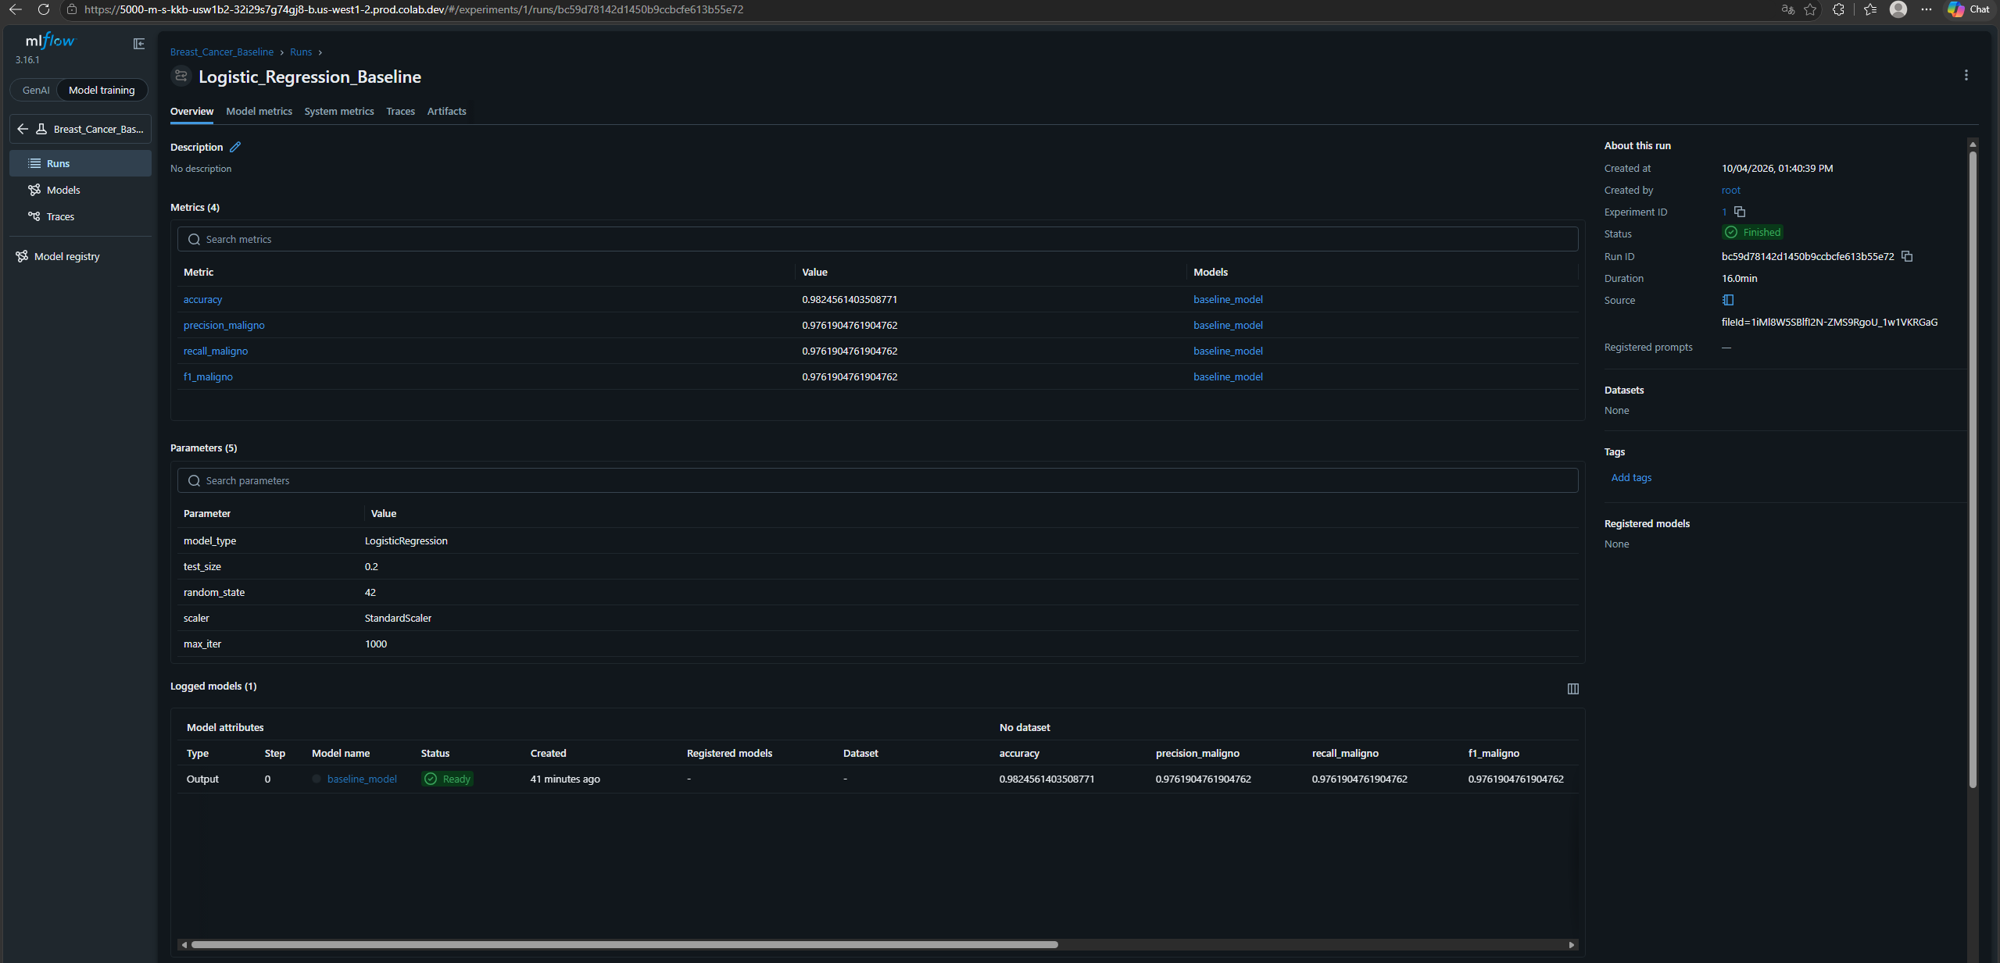

## 7. Reflexión final

A lo largo de esta actividad se recorrió un flujo básico de Machine Learning, desde la exploración y preparación de los datos hasta el entrenamiento, evaluación y registro de un modelo base. Aunque el resultado obtenido fue satisfactorio, el proceso todavía podría fortalecerse mediante prácticas de MLOps orientadas a mejorar la reproducibilidad, trazabilidad y automatización.

Una primera mejora sería versionar no solo el código, sino también los datos, parámetros y artefactos generados durante cada experimento. De esta forma sería posible comparar resultados de manera más confiable y reproducir exactamente una ejecución anterior. También sería conveniente automatizar el flujo mediante pipelines que integren preparación de datos, entrenamiento, evaluación y registro de métricas, reduciendo errores manuales y evitando diferencias entre ejecuciones.

Otra mejora importante sería incorporar validación cruzada y comparación sistemática entre distintos modelos, en lugar de depender de una sola división de entrenamiento y prueba. Asimismo, en un escenario productivo sería necesario monitorear el desempeño del modelo y detectar cambios en los datos o degradación de sus métricas con el paso del tiempo.

Estos aprendizajes se relacionan directamente con mi formación en ingeniería, análisis de datos e inteligencia artificial, ya que permiten pasar de un modelo que simplemente funciona en un notebook a un proceso estructurado, repetible y mantenible. En proyectos reales, esta disciplina resulta especialmente importante cuando varias personas trabajan con los mismos datos, cuando los experimentos evolucionan continuamente o cuando un modelo debe integrarse con otros sistemas. Por ello, considero que MLOps complementa el desarrollo técnico del Machine Learning al incorporar prácticas necesarias para llevar los modelos hacia soluciones confiables y sostenibles.